# Bank Marketing Campaign - MLflow Experiment Tracking

**Student**: Vaishnavi Sarmalkar  
**Course**: IE-7374 MLOps  
**Dataset**: Bank Marketing Campaign

## Overview

This notebook demonstrates MLflow for experiment tracking, model registration, and deployment using the Bank Marketing dataset to predict customer subscription to term deposits.


## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import mlflow
import mlflow.sklearn
import mlflow.pyfunc
from mlflow.models.signature import infer_signature
from mlflow.utils.environment import _mlflow_conda_env

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

import cloudpickle
import time
import warnings
import sklearn
warnings.filterwarnings('ignore')


## Step 2: Load Data

The Bank Marketing dataset contains information about marketing campaigns of a Portuguese banking institution.

In [2]:
# Load the bank marketing data
data = pd.read_csv("data/bank_marketing.csv", sep=";")

print(f"Dataset shape: {data.shape}")
print(f"\nFirst few rows:")
data.head()

Dataset shape: (41188, 21)

First few rows:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
# Check dataset info
print("Dataset Info:")
print("="*60)
data.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   4

## Step 3: Data Exploration

Target Variable (y) Distribution:
y
no     36548
yes     4640
Name: count, dtype: int64

Percentage:
y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64


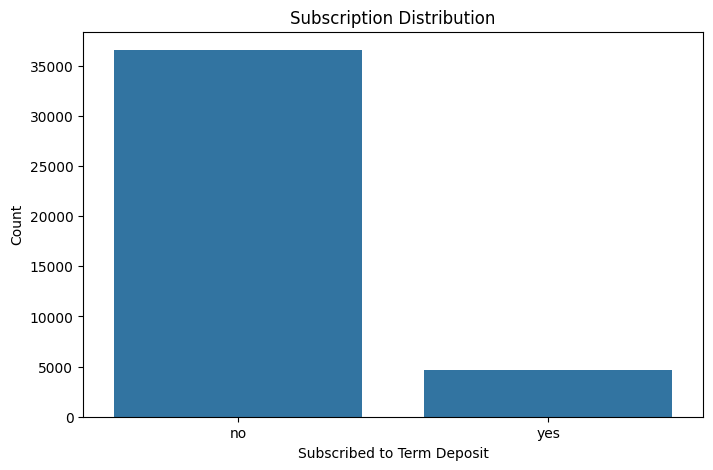

In [4]:
# Check target variable distribution
print("Target Variable (y) Distribution:")
print(data['y'].value_counts())
print(f"\nPercentage:")
print(data['y'].value_counts(normalize=True) * 100)

# Visualize
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='y')
plt.title('Subscription Distribution')
plt.xlabel('Subscribed to Term Deposit')
plt.ylabel('Count')
plt.show()

## Step 4: Data Preprocessing

We'll encode categorical variables and prepare the data for modeling.

In [5]:
# Create a copy for preprocessing
df = data.copy()

# Encode target variable (y)
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# List of categorical columns to encode
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 
                    'contact', 'month', 'day_of_week', 'poutcome']

# Label encode categorical variables
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

print("Categorical variables encoded")
print(f"\nDataset shape after encoding: {df.shape}")
df.head()

Categorical variables encoded

Dataset shape after encoding: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,3,1,0,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57,7,1,3,1,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37,7,1,3,0,2,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40,0,1,1,0,0,0,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56,7,1,3,0,0,2,1,6,1,...,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0


## Step 5: Check for Missing Data

In [6]:
# Check for missing values
missing = df.isna().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found!")

Missing values per column:
No missing values found!


## Step 6: Exploratory Data Analysis (EDA)

Let's visualize some key features and their relationship with subscription.

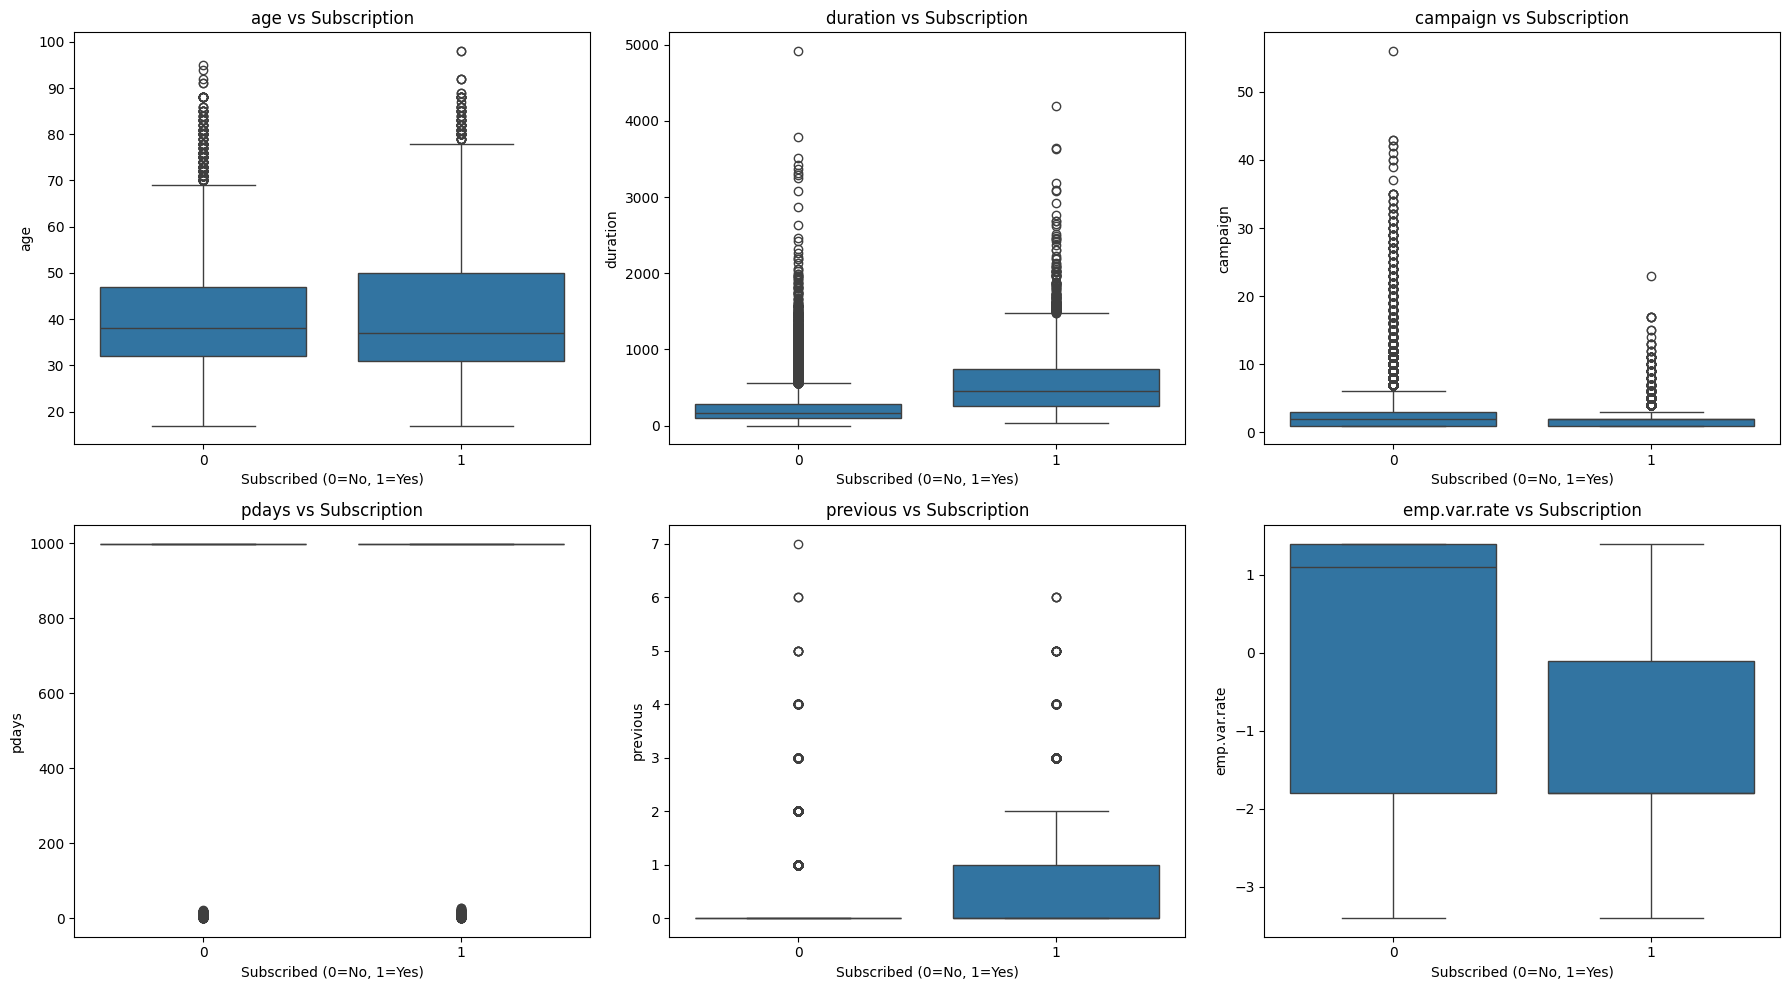

In [7]:
# Select numerical features for visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

numerical_features = ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate']

for idx, col in enumerate(numerical_features):
    row = idx // 3
    col_idx = idx % 3
    sns.boxplot(data=df, x='y', y=col, ax=axes[row, col_idx])
    axes[row, col_idx].set_title(f'{col} vs Subscription')
    axes[row, col_idx].set_xlabel('Subscribed (0=No, 1=Yes)')

plt.tight_layout()
plt.show()

## Step 7: Data Splitting

Split data into training (60%), validation (20%), and test (20%) sets.

In [8]:
# Separate features and target
X = df.drop(['y'], axis=1)
y = df['y']

# Split out the training data (60%)
X_train, X_rem, y_train, y_rem = train_test_split(
    X, y, train_size=0.6, random_state=42, stratify=y
)

# Split remaining data into validation and test (20% each)
X_val, X_test, y_val, y_test = train_test_split(
    X_rem, y_rem, test_size=0.5, random_state=42, stratify=y_rem
)

print("Data Split Summary:")
print("="*60)
print(f"Training set:   {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set:       {X_test.shape[0]} samples")
print(f"\nFeatures: {X_train.shape[1]}")

Data Split Summary:
Training set:   24712 samples
Validation set: 8238 samples
Test set:       8238 samples

Features: 20


## Step 8: Build Baseline Model with MLflow Tracking

We'll create a Random Forest baseline model and track it with MLflow.

In [9]:
# Wrapper class for predict_proba
class SklearnModelWrapper(mlflow.pyfunc.PythonModel):
    def __init__(self, model):
        self.model = model
    
    def predict(self, context, model_input):
        return self.model.predict_proba(model_input)[:, 1]

# Train baseline model with MLflow tracking
with mlflow.start_run(run_name='baseline_random_forest'):
    # Model parameters
    n_estimators = 100
    max_depth = 10
    
    # Create and train model
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=42
    )
    model.fit(X_train, y_train)
    
    # Make predictions
    predictions_test = model.predict_proba(X_test)[:, 1]
    predictions_binary = model.predict(X_test)
    
    # Calculate metrics
    auc_score = roc_auc_score(y_test, predictions_test)
    accuracy = accuracy_score(y_test, predictions_binary)
    
    # Log parameters
    mlflow.log_param('n_estimators', n_estimators)
    mlflow.log_param('max_depth', max_depth)
    
    # Log metrics
    mlflow.log_metric('auc', auc_score)
    mlflow.log_metric('accuracy', accuracy)
    
    # Wrap model
    wrapped_model = SklearnModelWrapper(model)
    
    # Infer signature
    signature = infer_signature(X_train, wrapped_model.predict(None, X_train))
    
    # Create conda environment
    conda_env = _mlflow_conda_env(
        additional_conda_deps=None,
        additional_pip_deps=[
            f"cloudpickle=={cloudpickle.__version__}",
            f"scikit-learn=={sklearn.__version__}"
        ],
        additional_conda_channels=None,
    )
    
    # Log model
    mlflow.pyfunc.log_model(
        "random_forest_model",
        python_model=wrapped_model,
        conda_env=conda_env,
        signature=signature
    )
    
    print("="*60)
    print("Baseline Model Results:")
    print("="*60)
    print(f"AUC: {auc_score:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print("="*60)

/Users/vaishnavisarmalkar/Documents/MLOps-Labs/MLflow_Lab/venv_mlflow/lib/python3.13/site-packages/mlflow/pyfunc/utils/data_validation.py:186: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
2026/03/21 14:14:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/21 14:14:15 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


Baseline Model Results:
AUC: 0.9504
Accuracy: 0.9156


## Step 9: Feature Importance Analysis

Top 10 Most Important Features:
                importance
duration          0.383726
nr.employed       0.109480
euribor3m         0.104448
pdays             0.057053
poutcome          0.046607
age               0.043372
cons.conf.idx     0.042961
emp.var.rate      0.031416
cons.price.idx    0.031407
month             0.023541


<Figure size 1000x600 with 0 Axes>

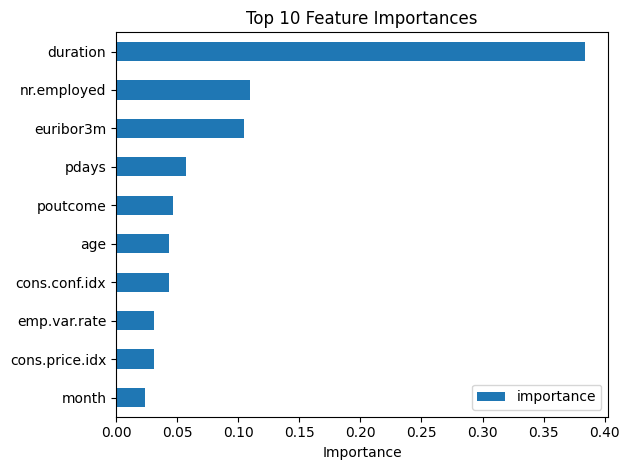

In [10]:
# Analyze feature importance
feature_importances = pd.DataFrame(
    model.feature_importances_,
    index=X_train.columns,
    columns=['importance']
).sort_values('importance', ascending=False)

print("Top 10 Most Important Features:")
print("="*60)
print(feature_importances.head(10))

# Visualize
plt.figure(figsize=(10, 6))
feature_importances.head(10).plot(kind='barh')
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Step 10: Register Model in MLflow Model Registry

In [11]:
# Get the run ID
run_id = mlflow.search_runs(
    filter_string='tags.mlflow.runName = "baseline_random_forest"'
).iloc[0].run_id

print(f"Run ID: {run_id}")

# Register the model
model_name = "bank_marketing_subscription"
model_version = mlflow.register_model(
    f"runs:/{run_id}/random_forest_model",
    model_name
)

# Wait for registration
time.sleep(10)

print(f" Model registered as: {model_name}")
print(f" Version: {model_version.version}")

Registered model 'bank_marketing_subscription' already exists. Creating a new version of this model...
2026/03/21 14:14:17 WARNING mlflow.tracking._model_registry.fluent: Run with id d0cffcef71054f50b46ee7798280f9d3 has no artifacts at artifact path 'random_forest_model', registering model based on models:/m-f95262d77d874a60b72b68bd9b20321b instead


Run ID: d0cffcef71054f50b46ee7798280f9d3


Created version '5' of model 'bank_marketing_subscription'.


 Model registered as: bank_marketing_subscription
 Version: 5


## Step 11: Transition Model to Production

In [12]:
from mlflow.tracking import MlflowClient

client = MlflowClient()

# Transition to Production
client.transition_model_version_stage(
    name=model_name,
    version=model_version.version,
    stage="Production"
)

print(f" Model version {model_version.version} transitioned to Production")
print(f" Model path: models:/{model_name}/production")

 Model version 5 transitioned to Production
 Model path: models:/bank_marketing_subscription/production


## Step 12: Load Production Model and Evaluate

In [13]:
# Load production model
production_model = mlflow.pyfunc.load_model(f"models:/{model_name}/production")

# Make predictions
test_predictions = production_model.predict(X_test)

# Calculate AUC
production_auc = roc_auc_score(y_test, test_predictions)

print("="*60)
print("Production Model Evaluation:")
print("="*60)
print(f"AUC: {production_auc:.4f}")
print("="*60)
print("\nThis should match the AUC from training!")

Production Model Evaluation:
AUC: 0.9504

This should match the AUC from training!


In [14]:
# Load production model
production_model = mlflow.pyfunc.load_model(f"models:/{model_name}/production")

# Make predictions
test_predictions = production_model.predict(X_test)

# Calculate AUC
production_auc = roc_auc_score(y_test, test_predictions)

print("="*60)
print("Production Model Evaluation:")
print("="*60)
print(f"Model: Random Forest Classifier")
print(f"AUC: {production_auc:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print("="*60)
print("\n MLflow experiment tracking completed successfully!")

Production Model Evaluation:
Model: Random Forest Classifier
AUC: 0.9504
Accuracy: 0.9156

 MLflow experiment tracking completed successfully!


In [15]:
# Load production model
production_model = mlflow.pyfunc.load_model(f"models:/{model_name}/production")

# Make predictions
test_predictions = production_model.predict(X_test)

# Calculate AUC
production_auc = roc_auc_score(y_test, test_predictions)

print("="*60)
print("Production Model Evaluation:")
print("="*60)
print(f"Model: Random Forest Classifier")
print(f"AUC: {production_auc:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print("="*60)
print("\n MLflow experiment tracking completed successfully!")

Production Model Evaluation:
Model: Random Forest Classifier
AUC: 0.9504
Accuracy: 0.9156

 MLflow experiment tracking completed successfully!
